# Initialize

In [4]:
import sys
import numpy as np
import pandas as pd
from scipy.special import erf
from scipy.integrate import quad
from scipy import interpolate
from scipy.interpolate import interp1d, interp2d
from scipy.interpolate import UnivariateSpline
import astropy
from astropy.coordinates import EarthLocation
import csv
from pylab import meshgrid,cm,imshow,contour,clabel,colorbar,axis,title,show
from numpy import exp,arange

# define isodetection angle

In [5]:
"""
calculate the local sidereal time (LAST) 
time is relative to midnight GMT 
arXiv:1312.1355
"""
def FracDays(date, time:np.array([0,0,0])):
    """
    fractional day number
    the zero of reference is 1 Jan 2000
    """
    n = 0
    
    d = date[0]
    m = date[1]
    y = date[2]
    
    h = time[0]
    minute = time[1]
    sec = time[2]
    
    if m == 1 or m == 2:
        Ytilde = y-1
        Mtilde = m+12
    else: 
        Ytilde = y
        Mtilde = m
    
    n += np.floor(365.25*Ytilde)+np.floor(30.61*(Mtilde+1))+d-730563.5+h/24+minute/(24*60)+sec/(24*60*60)
    return n
def GMST(n):
    T = n/36525
    return (86400*(0.7790572732640+0.00273781191135448*n+n%1)+0.00096707+307.47710227*T+0.092772113*T*T)%86400

def EqEq(n):
    T = n/36525
    Omega = np.deg2rad(125.04455501)-n*np.deg2rad(0.05295376)
    L=np.deg2rad(280.47)+n*np.deg2rad(0.98565)
    Dpsi = -1.1484*np.sin(Omega)-0.0864*np.sin(2*L)
    eA = np.deg2rad(23.4392794444)-0.01301021361*T**2
    return Dpsi*np.cos(eA)+0.000176*np.sin(Omega)+0.000004*np.sin(2*Omega)

def GAST(n):
    return GMST(n)+EqEq(n)

def LAST(n,lon):
    return (GAST(n)+lon/(2*np.pi)*86400)%86400

In [6]:
"""
Coordinate transformations
"""
def HelioEcliptic2Galactic(vec,T:0):
    arcsecond = np.deg2rad(1/3600) # 1/3600 degrees
    zetaA = 2306.083227*arcsecond*T + 0.298850*arcsecond*T**2
    zA = 2306.077181*arcsecond*T + 1.092735*arcsecond*T**2
    thetaA = 2004.191903*arcsecond*T - 0.429493*arcsecond*T**2
    
    P = np.array([
        [np.cos(zetaA)*np.cos(thetaA)*np.cos(zA) - 
     np.sin(zetaA)*np.sin(zA), -np.sin(zetaA)* np.cos(thetaA)*np.cos(zA) - 
     np.cos(zetaA)*np.sin(zA), -np.sin(thetaA)*np.cos(zA)],
        [np.cos(zetaA)*np.cos(thetaA)*np.sin(zA) + 
     np.sin(zetaA)*np.cos(zA),-np.sin(zetaA)*np.cos(thetaA)*np.sin(zA) + 
     np.cos(zetaA)*np.cos(zA),-np.sin(thetaA)*np.sin(zA)],
        [np.cos(zetaA)*np.sin(thetaA), -np.sin(zetaA)*np.sin(thetaA), np.cos(thetaA)]
    ]) 
    
    lCP = np.deg2rad(122.932) # degree
    alphaGP = np.deg2rad(192.85948) # degree
    deltaGP = np.deg2rad(27.12825) # degree
    
    M = np.array([[-np.sin(lCP)*np.sin(alphaGP)-np.cos(lCP)*np.cos(alphaGP)*np.sin(deltaGP),np.sin(lCP)*np.cos(alphaGP)-np.cos(lCP)*np.sin(alphaGP)*np.sin(deltaGP),np.cos(lCP)*np.cos(deltaGP)],
                  [np.cos(lCP)*np.sin(alphaGP)-np.sin(lCP)*np.cos(alphaGP)*np.sin(deltaGP),-np.cos(lCP)*np.cos(alphaGP)-np.sin(lCP)*np.sin(alphaGP)*np.sin(deltaGP),np.sin(lCP)*np.cos(deltaGP)],
                  [np.cos(alphaGP)*np.cos(deltaGP),np.sin(alphaGP)*np.cos(deltaGP),np.sin(deltaGP)]
                 ]
    )
    epsilon = np.deg2rad(23.4393) - np.deg2rad(0.0130)*T
    R = np.array([[1,0,0],[0,np.cos(epsilon),-np.sin(epsilon)],[0,np.sin(epsilon),np.cos(epsilon)]])
    prod1=-np.dot(M,np.linalg.inv(P))
    prod2=np.dot(R,vec)
    return np.dot(prod1,prod2)

def Equatorial2Galactic(vec,T:0):
    arcsecond = np.deg2rad(1/3600) # 1/3600 degrees
    zetaA = 2306.083227*arcsecond*T + 0.298850*arcsecond*T**2
    zA = 2306.077181*arcsecond*T + 1.092735*arcsecond*T**2
    thetaA = 2004.191903*arcsecond*T - 0.429493*arcsecond*T**2
    
    P = np.array([
        [np.cos(zetaA)*np.cos(thetaA)*np.cos(zA) - 
     np.sin(zetaA)*np.sin(zA), -np.sin(zetaA)* np.cos(thetaA)*np.cos(zA) - 
     np.cos(zetaA)*np.sin(zA), -np.sin(thetaA)*np.cos(zA)],
        [np.cos(zetaA)*np.cos(thetaA)*np.sin(zA) + 
     np.sin(zetaA)*np.cos(zA),-np.sin(zetaA)*np.cos(thetaA)*np.sin(zA) + 
     np.cos(zetaA)*np.cos(zA),-np.sin(thetaA)*np.sin(zA)],
        [np.cos(zetaA)*np.sin(thetaA), -np.sin(zetaA)*np.sin(thetaA), np.cos(thetaA)]
    ]) 
    
    lCP = np.deg2rad(122.932) # degree
    alphaGP = np.deg2rad(192.85948) # degree
    deltaGP = np.deg2rad(27.12825) # degree
    
    M = np.array([[-np.sin(lCP)*np.sin(alphaGP)-np.cos(lCP)*np.cos(alphaGP)*np.sin(deltaGP),np.sin(lCP)*np.cos(alphaGP)-np.cos(lCP)*np.sin(alphaGP)*np.sin(deltaGP),np.cos(lCP)*np.cos(deltaGP)],
                  [np.cos(lCP)*np.sin(alphaGP)-np.sin(lCP)*np.cos(alphaGP)*np.sin(deltaGP),-np.cos(lCP)*np.cos(alphaGP)-np.sin(lCP)*np.sin(alphaGP)*np.sin(deltaGP),np.sin(lCP)*np.cos(deltaGP)],
                  [np.cos(alphaGP)*np.cos(deltaGP),np.sin(alphaGP)*np.cos(deltaGP),np.sin(deltaGP)]
                 ]
    )

    prod1 = np.dot(M,np.linalg.inv(P))
    return np.dot(prod1,vec)

"""
Earth's velocity
"""
def ve(n):
    vEavg = 29.79 # km/s
    vr = np.asarray([0,220,0]) # galactic rotation km/s
    vs = np.asarray([11.1,12.2,7.3]) # sun's relative motion km/s
    L=np.deg2rad(280.460)+np.deg2rad(0.9856474)*n # mean longitude
    ee = 0.01671 # ellipticity of Earth's orbit
    omega = np.deg2rad(282.932)+np.deg2rad(0.0000471)*n # perihilion longitude
    T=n/36525
    ex = np.array([1,0,0])
    ey = np.array([0,1,0])
    uE=-vEavg*(np.sin(L)+ee*np.sin(2*L-omega))*HelioEcliptic2Galactic(ex,T)+vEavg*(np.cos(L)+ee*np.cos(2*L-omega))*HelioEcliptic2Galactic(ey,T)
    return vr+vs+uE
"""
Laboratory position
"""
def LabPos(lat,lon,depth,n):
    r = 6371 - depth # km
    theta = np.pi/2-lat
    phi = 2*np.pi/86400*LAST(n,lon)
    coord = np.array([r*np.sin(theta)*np.cos(phi),r*np.sin(theta)*np.sin(phi),r*np.cos(theta)])
    return Equatorial2Galactic(coord,n/36525)

In [7]:
def ThetaIso(loc,n):
    """
    returns Isodetection angle in radians
    """
    lat = loc[0]
    lon = loc[1]
    depth = loc[2]
    
    vector_1 = ve(n)
    vector_2 = LabPos(lat,lon,depth,n)
    unit_vector_1 = vector_1 / np.linalg.norm(vector_1)
    unit_vector_2 = vector_2 / np.linalg.norm(vector_2)
    dot_product = np.dot(unit_vector_1, unit_vector_2)
    angle = np.arccos(dot_product)
    return angle

In [8]:
brc=EarthLocation.of_address('San Carlos de Bariloche, Argentina')
sg=EarthLocation.of_address('Sierra Grande, Argentina')
fnal=EarthLocation.of_address('Fermilab, USA')
sno=EarthLocation.of_address('Snolab, Canada')
gssi=EarthLocation.of_address('Gran Sasso, Italy')
modane=EarthLocation.of_address('Modane, France')
soudan=EarthLocation.of_address('Soudan, USA')
# lat [rad], lon [rad], depth [km]
sites = {'BRC': {'loc':[brc.lat.to_value('radian'), brc.lon.to_value('radian'), 0]}, \
         'SG': {'loc':[sg.lat.to_value('radian'), sg.lon.to_value('radian'), 0.4]}, \
            'FNAL': {'loc':[fnal.lat.to_value('radian'), fnal.lon.to_value('radian'), 0.105]}, \
            'SNO': {'loc':[sno.lat.to_value('radian'), sno.lon.to_value('radian'), 2]},
            'GS': {'loc':[gssi.lat.to_value('radian'), gssi.lon.to_value('radian'), 3.1]},
            'SURF': {'loc':[soudan.lat.to_value('radian'), soudan.lon.to_value('radian'), 2.4]}
      }

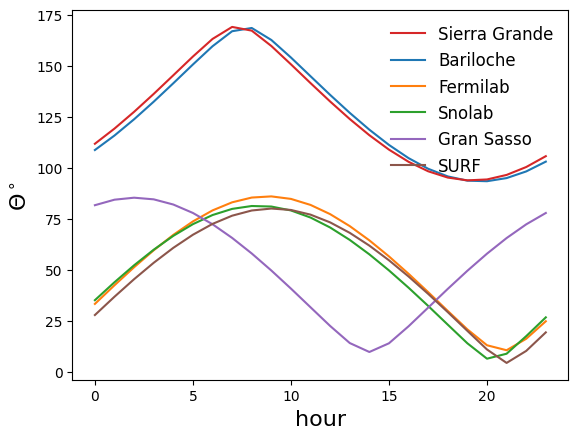

In [10]:
import matplotlib.pyplot as plt
hlist = [h for h in range(24)]
nlist1 = [FracDays(np.array([12,12,2020]),np.array([h,0,0])) for h in range(24)]
nlist2 = [FracDays(np.array([30,12,2020]),np.array([h,0,0])) for h in range(24)]
fig, ax = plt.subplots()
isoBRC, = ax.plot(hlist,[np.rad2deg(ThetaIso(sites['BRC']['loc'],n)) for n in nlist1], label='Bariloche')
isoFNAL, = ax.plot(hlist,[np.rad2deg(ThetaIso(sites['FNAL']['loc'],n)) for n in nlist1], label='Fermilab')
isoSNO, = ax.plot(hlist,[np.rad2deg(ThetaIso(sites['SNO']['loc'],n)) for n in nlist1], label='Snolab')
isoSG, = ax.plot(hlist,[np.rad2deg(ThetaIso(sites['SG']['loc'],n)) for n in nlist1], label='Sierra Grande')
isoGS, = ax.plot(hlist,[np.rad2deg(ThetaIso(sites['GS']['loc'],n)) for n in nlist1], label='Gran Sasso')
isoSURF, = ax.plot(hlist,[np.rad2deg(ThetaIso(sites['SURF']['loc'],n)) for n in nlist1], label='SURF')

ax.set_xlabel('hour',fontsize=16)
ax.set_ylabel(r'$\Theta^\circ$',fontsize=16)
first_legend = ax.legend(handles=[isoSG,isoBRC,isoFNAL,isoSNO,isoGS,isoSURF], loc = 'upper right',frameon=False, fontsize=12)
plt.show(first_legend)
plt.show()
#fig.savefig(FigDir+'Iso_Theta.pdf',bbox_inches='tight')